# Man vs Machine on Oslo Børs — Portfolio Simulation

This notebook backtests the model predictions from the Machine Learning notebook as tradable monthly portfolios, for both the historical and modern tracks. For each signal, a Long-Only strategy (top 20% of predicted returns) and a Long-Short strategy (top 20% long, bottom 20% short) are simulated with realistic transaction costs, and compared against a traditional 12-month momentum baseline and the Oslo Børs market benchmark.

**Input:** `historical_predictions.csv`, `modern_predictions.csv`, `modern_equity_dataset.csv`, `investable_universe.csv`, `Norway_market_portfolios_monthly.csv`
**Output:** `portfolio_simulation_returns_mod.csv`, `portfolio_simulation_returns_hist.csv`, cumulative return plots, and an Information Coefficient summary table.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Setup

The ML notebook's prediction files don't carry the raw 12-month momentum feature needed as a baseline comparison, so it is merged back in from the original feature datasets. The simulation window is also capped at the last month with a complete forward return.

In [15]:
# Load model predictions
df_mod = pd.read_csv('../Data/modern_predictions.csv')
df_hist = pd.read_csv('../Data/historical_predictions.csv')

df_mod['TradeDate'] = pd.to_datetime(df_mod['TradeDate'])
df_hist['TradeDate'] = pd.to_datetime(df_hist['TradeDate'])

# Merge the traditional 12-month momentum feature back in as a baseline signal
print("Fetching original momentum features...")
orig_mod = pd.read_csv('../Data/modern_equity_dataset.csv', usecols=['TradeDate', 'ISIN', 'mom_12m_z'])
orig_hist = pd.read_csv('../Data/investable_universe.csv', usecols=['TradeDate', 'ISIN', 'mom_12m_z'])

orig_mod['TradeDate'] = pd.to_datetime(orig_mod['TradeDate'])
orig_hist['TradeDate'] = pd.to_datetime(orig_hist['TradeDate'])

df_mod = pd.merge(df_mod, orig_mod, on=['TradeDate', 'ISIN'], how='left')
df_hist = pd.merge(df_hist, orig_hist, on=['TradeDate', 'ISIN'], how='left')

df_mod = df_mod.sort_values(['TradeDate', 'ISIN']).reset_index(drop=True)
df_hist = df_hist.sort_values(['TradeDate', 'ISIN']).reset_index(drop=True)

# Transaction cost assumption and simulation window
TC_BPS = 0.0015
SIM_END_DATE = pd.to_datetime('2024-11-30')

df_mod = df_mod[df_mod['TradeDate'] <= SIM_END_DATE]
df_hist = df_hist[df_hist['TradeDate'] <= SIM_END_DATE]

print("Data loaded and momentum merged successfully.")
print(f"Modern rows: {df_mod.shape[0]} | Historical rows: {df_hist.shape[0]}")

Fetching original momentum features...
Data loaded and momentum merged successfully.
Modern rows: 10020 | Historical rows: 10020


In [16]:
# Load Ødegaard's Norway market portfolios (value-weighted 'VW' index used as the market benchmark)
mkt_df = pd.read_csv('../Data/Norway_market_portfolios_monthly.csv')
mkt_df['TradeDate'] = pd.to_datetime(mkt_df['date'], format='%Y%m%d') + pd.offsets.MonthEnd(0)
mkt_df = mkt_df[['TradeDate', 'VW']]

## 2. Simulation Functions

Two building blocks drive the backtest: a monthly portfolio-weighting function that sorts stocks into Long-Only and Long-Short baskets based on the model's predicted return, and a backtest engine that steps through each month, applies those weights, and nets out transaction costs based on portfolio turnover.

In [17]:
def get_portfolio_weights(month_df, signal_col, quantile=0.20):
    """
    Takes a dataframe for a single month and returns target portfolio weights.
    Returns weights for both a Long-Only and a Long-Short strategy.
    """
    # Cutoff thresholds for the top and bottom quantiles
    top_cutoff = month_df[signal_col].quantile(1 - quantile)
    bottom_cutoff = month_df[signal_col].quantile(quantile)

    # Stocks in the long and short baskets
    long_basket = month_df[month_df[signal_col] >= top_cutoff]
    short_basket = month_df[month_df[signal_col] <= bottom_cutoff]

    # Equal-weight within each basket
    n_long = len(long_basket)
    long_only_weights = pd.Series(1.0 / n_long, index=long_basket.index) if n_long > 0 else pd.Series(dtype=float)

    # Long-Short: +100% in longs, -100% in shorts (dollar neutral)
    n_short = len(short_basket)
    short_weights = pd.Series(-1.0 / n_short, index=short_basket.index) if n_short > 0 else pd.Series(dtype=float)

    long_short_weights = pd.concat([long_only_weights, short_weights])

    return long_only_weights, long_short_weights

In [18]:
def run_backtest(df, signal_col, quantile=0.20, tc_rate=0.0015):
    """
    Simulates trading month-by-month, accounting for turnover and transaction costs.
    """
    dates = sorted(df['TradeDate'].unique())
    results = []

    # Track the previous month's weights to calculate turnover
    prev_weights_lo = pd.Series(dtype=float)
    prev_weights_ls = pd.Series(dtype=float)

    for date in dates:
        current_month_data = df[df['TradeDate'] == date].set_index('ISIN')

        # Target weights based on the model's predictions
        curr_weights_lo, curr_weights_ls = get_portfolio_weights(
            current_month_data, signal_col=signal_col, quantile=quantile
        )

        # Actual future returns (Target_raw is already shifted to represent t+1 return)
        future_returns = current_month_data['Target_raw'].fillna(0)

        # Gross returns (dot product of weights and realized returns)
        gross_ret_lo = (curr_weights_lo * future_returns.reindex(curr_weights_lo.index).fillna(0)).sum()
        gross_ret_ls = (curr_weights_ls * future_returns.reindex(curr_weights_ls.index).fillna(0)).sum()

        # Benchmark: equal weight over the entire universe that month
        gross_ret_bm = future_returns.mean()

        # Turnover: absolute change in weights vs. the previous month
        all_isins_lo = curr_weights_lo.index.union(prev_weights_lo.index)
        turnover_lo = (curr_weights_lo.reindex(all_isins_lo).fillna(0) - prev_weights_lo.reindex(all_isins_lo).fillna(0)).abs().sum()

        all_isins_ls = curr_weights_ls.index.union(prev_weights_ls.index)
        turnover_ls = (curr_weights_ls.reindex(all_isins_ls).fillna(0) - prev_weights_ls.reindex(all_isins_ls).fillna(0)).abs().sum()

        # Benchmark turnover: naive assumption of ~10% monthly turnover for an equal-weight index
        turnover_bm = 0.10

        # Net returns after transaction costs
        net_ret_lo = gross_ret_lo - (turnover_lo * tc_rate)
        net_ret_ls = gross_ret_ls - (turnover_ls * tc_rate)
        net_ret_bm = gross_ret_bm - (turnover_bm * tc_rate)

        results.append({
            'TradeDate': date,
            'Net_Ret_LongOnly': net_ret_lo,
            'Net_Ret_LongShort': net_ret_ls,
            'Net_Ret_Benchmark': net_ret_bm,
            'Turnover_LongOnly': turnover_lo,
            'Turnover_LongShort': turnover_ls
        })

        prev_weights_lo = curr_weights_lo
        prev_weights_ls = curr_weights_ls

    results_df = pd.DataFrame(results).set_index('TradeDate')
    return results_df

## 3. Run Backtests

Each model's signal is backtested independently, along with the traditional momentum baseline, so their net-of-cost returns can be compared directly.

In [19]:
print("Running simulations...\n")

sim_mod_en = run_backtest(df_mod, signal_col='Ensemble_Pred_z', quantile=0.20, tc_rate=TC_BPS)
sim_hist_en = run_backtest(df_hist, signal_col='Ensemble_Pred_z', quantile=0.20, tc_rate=TC_BPS)
sim_mod_xgb = run_backtest(df_mod, signal_col='XGBoost_Pred_z', quantile=0.20, tc_rate=TC_BPS)
sim_hist_xgb = run_backtest(df_hist, signal_col='XGBoost_Pred_z', quantile=0.20, tc_rate=TC_BPS)
# Traditional momentum baseline (using modern-track dates for a fair comparison)
sim_mod_mom = run_backtest(df_mod, signal_col='mom_12m_z', quantile=0.20, tc_rate=TC_BPS)

print("Simulations complete.")

Running simulations...

Simulations complete.


## 4. Information Coefficient (IC)

The Rank Information Coefficient measures how well each signal's cross-sectional ranking predicts next-month returns, independent of the portfolio construction choices above. It is calculated as the monthly Spearman rank correlation between the signal and the realized forward return, averaged across the sample.

In [20]:
print("Calculating Rank Information Coefficient (IC) across the full universe...\n")

def calculate_monthly_ic(df, pred_col, model_name, target_col='Target_raw', date_col='TradeDate'):
    ics = []

    for date, group in df.groupby(date_col):
        valid_data = group[[pred_col, target_col]].dropna()

        # Require at least 5 stocks in a month for a meaningful correlation
        if len(valid_data) < 5:
            continue

        ic, _ = spearmanr(valid_data[pred_col], valid_data[target_col])
        ics.append(ic)

    ics = pd.Series(ics)

    mean_ic = ics.mean()
    ic_vol = ics.std()
    ic_ir = mean_ic / ic_vol if ic_vol > 0 else 0
    pct_positive = (ics > 0).mean()

    return {
        'Strategy / Model': model_name,
        'Mean_IC': mean_ic,
        'IC_IR': ic_ir,
        '%_Positive_Months': pct_positive
    }

models_to_evaluate = [
    (df_mod, 'Ensemble_Pred_z', 'Modern Ensemble'),
    (df_hist, 'Ensemble_Pred_z', 'Historical Ensemble'),
    (df_mod, 'RandomForest_Pred_z', 'Modern Random Forest'),
    (df_hist, 'RandomForest_Pred_z', 'Historical Random Forest'),
    (df_mod, 'mom_12m_z', 'Traditional Momentum (Modern Dataset)'),
    (df_hist, 'mom_12m_z', 'Traditional Momentum (Historical Dataset)')
]

ic_results = []
for df, signal_col, model_name in models_to_evaluate:
    if signal_col in df.columns:
        res = calculate_monthly_ic(df, pred_col=signal_col, model_name=model_name, target_col='Target_raw')
        ic_results.append(res)

ic_table = pd.DataFrame(ic_results)
ic_table['Mean_IC'] = ic_table['Mean_IC'].map('{:+.4f}'.format)
ic_table['IC_IR'] = ic_table['IC_IR'].map('{:+.3f}'.format)
ic_table['%_Positive_Months'] = ic_table['%_Positive_Months'].map('{:.1%}'.format)

print("=== Rank IC Summary Table ===")
display(ic_table)

Calculating Rank Information Coefficient (IC) across the full universe...

=== Rank IC Summary Table ===


,Strategy / Model,Mean_IC,IC_IR,%_Positive_Months
0,Modern Ensemble,+0.1241,+0.943,80.0%
1,Historical Ensemble,+0.1286,+0.941,77.1%
2,Modern Random Forest,+0.1058,+0.900,74.3%
3,Historical Random Forest,+0.1183,+0.961,77.1%
4,Traditional Momentum (Modern Dataset),+0.1051,+0.886,77.1%
5,Traditional Momentum (Historical Dataset),+0.1051,+0.886,77.1%


## 5. Visualization

Cumulative net returns are plotted on a log scale so that compounding growth across very different strategies remains comparable. The value-weighted (VW) Ødegaard market index is included alongside the equal-weighted benchmark computed within the backtest, and both Long-Only and Long-Short charts share the same y-axis range for a fair visual comparison.

In [21]:
# Align the VW market index to the simulation dates
vw_returns = mkt_df.set_index('TradeDate')['VW'].reindex(sim_mod_en.index).fillna(0)

# Global y-axis limits so both charts share an identical, comparable scale
all_returns = pd.concat([
    sim_mod_en['Net_Ret_LongOnly'], sim_hist_en['Net_Ret_LongOnly'],
    sim_mod_xgb['Net_Ret_LongOnly'], sim_hist_xgb['Net_Ret_LongOnly'],
    sim_mod_mom['Net_Ret_LongOnly'], sim_mod_en['Net_Ret_Benchmark'], vw_returns,
    sim_mod_en['Net_Ret_LongShort'], sim_hist_en['Net_Ret_LongShort'],
    sim_hist_xgb['Net_Ret_LongShort'], sim_mod_xgb['Net_Ret_LongShort'], sim_mod_mom['Net_Ret_LongShort']
], axis=1)

global_cum_rets = (1 + all_returns).cumprod()
y_min = global_cum_rets.min().min() * 0.9
y_max = global_cum_rets.max().max() * 1.1

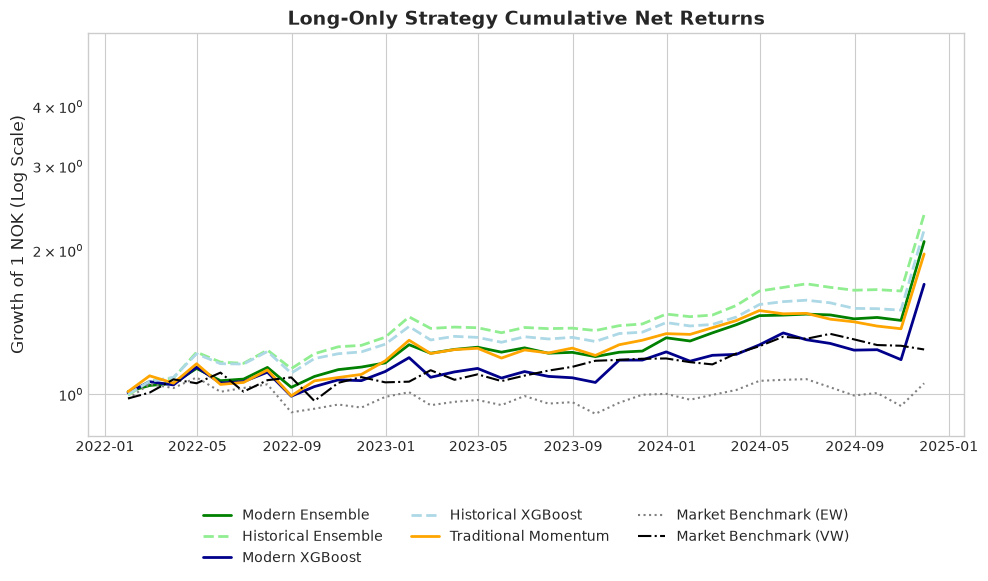

In [22]:
# --- Long-Only (Mutual Fund) ---
plt.figure(figsize=(10, 6))
plt.plot((1 + sim_mod_en['Net_Ret_LongOnly']).cumprod(), label='Modern Ensemble', color='green', linewidth=2)
plt.plot((1 + sim_hist_en['Net_Ret_LongOnly']).cumprod(), label='Historical Ensemble', color='lightgreen', linewidth=2, linestyle='--')
plt.plot((1 + sim_mod_xgb['Net_Ret_LongOnly']).cumprod(), label='Modern XGBoost', color='darkblue', linewidth=2)
plt.plot((1 + sim_hist_xgb['Net_Ret_LongOnly']).cumprod(), label='Historical XGBoost', color='lightblue', linewidth=2, linestyle='--')
plt.plot((1 + sim_mod_mom['Net_Ret_LongOnly']).cumprod(), label='Traditional Momentum', color='orange', linewidth=2)
plt.plot((1 + sim_mod_en['Net_Ret_Benchmark']).cumprod(), label='Market Benchmark (EW)', color='gray', linestyle=':')
plt.plot((1 + vw_returns).cumprod(), label='Market Benchmark (VW)', color='black', linestyle='-.')

plt.title('Long-Only Strategy Cumulative Net Returns', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.ylim(y_min, y_max)
plt.ylabel('Growth of 1 NOK (Log Scale)', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

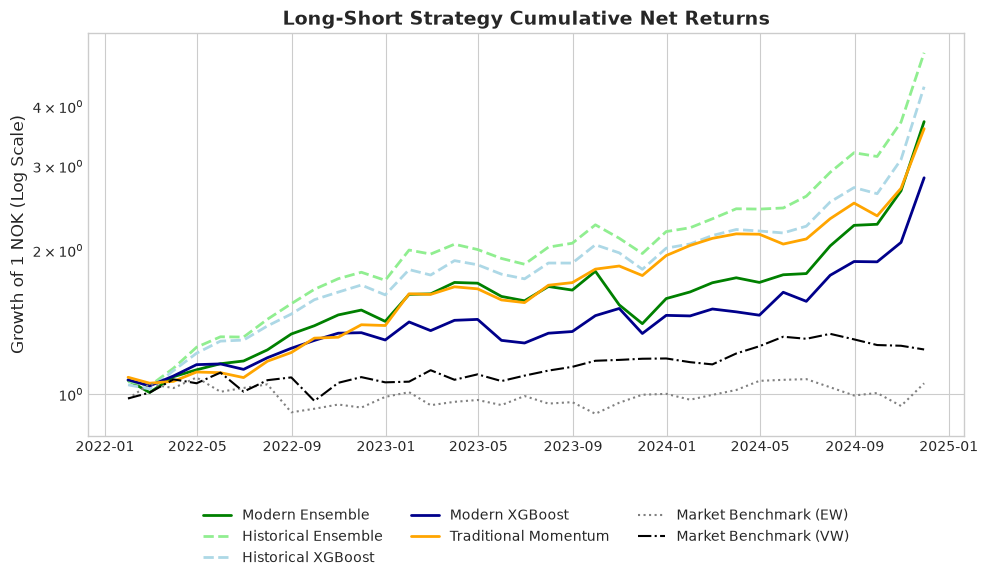

In [23]:
# --- Long-Short (Hedge Fund) ---
plt.figure(figsize=(10, 6))
plt.plot((1 + sim_mod_en['Net_Ret_LongShort']).cumprod(), label='Modern Ensemble', color='green', linewidth=2)
plt.plot((1 + sim_hist_en['Net_Ret_LongShort']).cumprod(), label='Historical Ensemble', color='lightgreen', linewidth=2, linestyle='--')
plt.plot((1 + sim_hist_xgb['Net_Ret_LongShort']).cumprod(), label='Historical XGBoost', color='lightblue', linewidth=2, linestyle='--')
plt.plot((1 + sim_mod_xgb['Net_Ret_LongShort']).cumprod(), label='Modern XGBoost', color='darkblue', linewidth=2)
plt.plot((1 + sim_mod_mom['Net_Ret_LongShort']).cumprod(), label='Traditional Momentum', color='orange', linewidth=2)
plt.plot((1 + sim_mod_en['Net_Ret_Benchmark']).cumprod(), label='Market Benchmark (EW)', color='gray', linestyle=':')
plt.plot((1 + vw_returns).cumprod(), label='Market Benchmark (VW)', color='black', linestyle='-.')

plt.title('Long-Short Strategy Cumulative Net Returns', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.ylim(y_min, y_max)
plt.ylabel('Growth of 1 NOK (Log Scale)', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

## 6. Summary Statistics

Annualized net returns and average monthly Long-Short turnover for each strategy, alongside both market benchmarks.

In [24]:
summary_data = {
    'Strategy': [
        'Modern Ensemble', 'Historical Ensemble',
        'Modern XGBoost', 'Historical XGBoost',
        'Traditional Momentum', 'Market Benchmark (EW)',
        'Market Benchmark (VW)'
    ],
    'Ann_Ret_LongOnly': [
        sim_mod_en['Net_Ret_LongOnly'].mean() * 12,
        sim_hist_en['Net_Ret_LongOnly'].mean() * 12,
        sim_mod_xgb['Net_Ret_LongOnly'].mean() * 12,
        sim_hist_xgb['Net_Ret_LongOnly'].mean() * 12,
        sim_mod_mom['Net_Ret_LongOnly'].mean() * 12,
        sim_mod_en['Net_Ret_Benchmark'].mean() * 12,
        vw_returns.mean() * 12
    ],
    'Ann_Ret_LongShort': [
        sim_mod_en['Net_Ret_LongShort'].mean() * 12,
        sim_hist_en['Net_Ret_LongShort'].mean() * 12,
        sim_mod_xgb['Net_Ret_LongShort'].mean() * 12,
        sim_hist_xgb['Net_Ret_LongShort'].mean() * 12,
        sim_mod_mom['Net_Ret_LongShort'].mean() * 12,
        None,  # Benchmarks cannot be Long-Short
        None
    ],
    'Turnover_LongShort': [
        sim_mod_en['Turnover_LongShort'].mean(),
        sim_hist_en['Turnover_LongShort'].mean(),
        sim_mod_xgb['Turnover_LongShort'].mean(),
        sim_hist_xgb['Turnover_LongShort'].mean(),
        sim_mod_mom['Turnover_LongShort'].mean(),
        None,
        None
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Ann_Ret_LongOnly'] = summary_df['Ann_Ret_LongOnly'].map('{:.2%}'.format)
summary_df['Ann_Ret_LongShort'] = summary_df['Ann_Ret_LongShort'].apply(lambda x: '{:.2%}'.format(x) if pd.notnull(x) else 'N/A')
summary_df['Turnover_LongShort'] = summary_df['Turnover_LongShort'].apply(lambda x: '{:.2f}'.format(x) if pd.notnull(x) else 'N/A')

print("=== Simulation Summary Statistics ===")
display(summary_df)

=== Simulation Summary Statistics ===


,Strategy,Ann_Ret_LongOnly,Ann_Ret_LongShort,Turnover_LongShort
0,Modern Ensemble,28.87%,50.26%,1.36
1,Historical Ensemble,33.50%,61.49%,1.28
2,Modern XGBoost,22.11%,39.65%,1.46
3,Historical XGBoost,31.15%,55.70%,1.40
4,Traditional Momentum,27.15%,47.53%,0.90
5,Market Benchmark (EW),3.06%,N/A,N/A
6,Market Benchmark (VW),8.41%,N/A,N/A


## 7. Export for Evaluation Notebook

The Modern Ensemble's return series is saved as the primary dataset for the Evaluation notebook, with the Long-Short returns of the other strategies attached as extra columns so their alpha regressions can also be run if needed.

In [25]:
final_export_mod = sim_mod_en.copy()
final_export_mod['Net_Ret_Modern_XGB_LS'] = sim_mod_xgb['Net_Ret_LongShort']
final_export_mod['Net_Ret_Mom_LS'] = sim_mod_mom['Net_Ret_LongShort']

final_export_hist = sim_hist_en.copy()
final_export_hist['Net_Ret_Hist_XGB_LS'] = sim_hist_xgb['Net_Ret_LongShort']

final_export_mod.to_csv('../Data/portfolio_simulation_returns_mod.csv')
final_export_hist.to_csv('../Data/portfolio_simulation_returns_hist.csv')

print("Portfolio returns exported to 'portfolio_simulation_returns_mod.csv' and 'portfolio_simulation_returns_hist.csv' for the Evaluation notebook.")

Portfolio returns exported to 'portfolio_simulation_returns_mod.csv' and 'portfolio_simulation_returns_hist.csv' for the Evaluation notebook.
